# PPM calibrato su `climate_19` 
## Fit del Planted Partition Model dalla rete reale + esperimenti su repliche sintetiche




Dalla rete reale stimiamo:
- **p_int**: probabilità di arco *dentro* ogni comunità (A e B separatamente)
- **p_ext**: probabilità di arco *tra* le due comunità
- **μ**: mixing parameter per A e B

$$p_{int} = \frac{2 L_C}{|C|(|C|-1)}, \quad p_{ext} = \frac{L_{AB}}{|A| \cdot |B|}, \quad \mu = \frac{\langle k_{ext} \rangle}{\langle k \rangle}$$


In [2]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

RNG_SEED = 42
np.random.seed(RNG_SEED)

# ── Caricamento ──────────────────────────────────────────────────────────
g_real = ig.Graph.Read_GraphML(r"C:\Users\giuli\OneDrive\Documenti\UNI\MAGISTRALE\AnalVisual\AVRC_FinnishTwittersphereProject\Data\climate_19.graphml")
if g_real.is_directed():
    g_real = g_real.as_undirected(combine_edges="first")

N_real = g_real.vcount()
E_real = g_real.ecount()
k_avg_real = 2 * E_real / N_real

group_attr = g_real.vs["group"]
hier_attr  = g_real.vs["hierarchy"]

idx_A = [v.index for v in g_real.vs if v["group"] == "A"]
idx_B = [v.index for v in g_real.vs if v["group"] == "B"]
nA, nB = len(idx_A), len(idx_B)

# ── Stima parametri PPM ───────────────────────────────────────────────────
set_A, set_B = set(idx_A), set(idx_B)
L_A, L_B, L_AB = 0, 0, 0
for e in g_real.es:
    u, v = e.source, e.target
    in_A_u, in_A_v = u in set_A, v in set_A
    if in_A_u and in_A_v:       L_A  += 1
    elif not in_A_u and not in_A_v: L_B += 1
    else:                           L_AB += 1

p_int_A = 2 * L_A  / (nA * (nA - 1))
p_int_B = 2 * L_B  / (nB * (nB - 1))
p_ext   = L_AB     / (nA * nB)
p_int   = (p_int_A + p_int_B) / 2   # media tra le due comunità

k_int_A = p_int_A * (nA - 1)
k_int_B = p_int_B * (nB - 1)
k_ext_A = p_ext   * nB
k_ext_B = p_ext   * nA
mu_A    = k_ext_A / (k_int_A + k_ext_A)
mu_B    = k_ext_B / (k_int_B + k_ext_B)
mu_mean = (mu_A + mu_B) / 2

print("=" * 52)
print(f"  Rete climate_19")
print(f"  N = {N_real:,}   E = {E_real:,}   ⟨k⟩ = {k_avg_real:.3f}")
print("=" * 52)
print(f"  |A| = {nA:,}   |B| = {nB:,}")
print(f"  L_A = {L_A:,}   L_B = {L_B:,}   L_AB = {L_AB:,}")
print()
print(f"  p_int_A = {p_int_A:.6f}")
print(f"  p_int_B = {p_int_B:.6f}")
print(f"  p_int   = {p_int:.6f}  (media)")
print(f"  p_ext   = {p_ext:.6f}")
print()
print(f"  μ_A  = {mu_A:.4f}  (comunità A)")
print(f"  μ_B  = {mu_B:.4f}  (comunità B)")
print(f"  μ    = {mu_mean:.4f}  (media — usato come μ di riferimento)")
print()
print(f"  Le comunità sono ben separate (μ << 0.5): struttura forte.")


  Rete climate_19
  N = 16,639   E = 50,605   ⟨k⟩ = 6.083
  |A| = 7,409   |B| = 9,230
  L_A = 28,384   L_B = 17,487   L_AB = 4,734

  p_int_A = 0.001034
  p_int_B = 0.000411
  p_int   = 0.000722  (media)
  p_ext   = 0.000069

  μ_A  = 0.0770  (comunità A)
  μ_B  = 0.1192  (comunità B)
  μ    = 0.0981  (media — usato come μ di riferimento)

  Le comunità sono ben separate (μ << 0.5): struttura forte.



Il PPM viene costruito campionando archi con probabilità p_int dentro ogni blocco
e p_ext tra blocchi diversi.

Per q > 2 distribuiamo i nodi in q blocchi di dimensione N/q e usiamo una **p_int
comune** (la media tra A e B stimata dalla rete reale) e la stessa **p_ext**.


In [15]:
def make_ppm_climate(N, q, p_int, p_ext, seed=RNG_SEED):
    """
    Genera un PPM con parametri calibrati da climate_19.
    Blocchi di dimensione N//q (l'ultimo blocco può avere un nodo in meno
    se N non è divisibile per q).
    """
    rng_local = np.random.default_rng(seed)
    nc = N // q
    # assegna ogni nodo a un blocco
    block = []
    for c in range(q):
        size = nc if c < q - 1 else N - nc * (q - 1)
        block.extend([c] * size)
    block = np.array(block)

    g = ig.Graph(N)
    edges = []
    for u in range(N):
        for v in range(u + 1, N):
            p = p_int if block[u] == block[v] else p_ext
            if rng_local.random() < p:
                edges.append((u, v))
    g.add_edges(edges)
    return g, block.tolist()


def detect_and_score(g, gt):
    """Louvain (modularity) + NMI, ARI, Q, k."""
    vc   = g.community_multilevel(weights=None)
    memb = vc.membership
    Q    = g.modularity(memb)
    k    = len(set(memb))
    nmi  = ig.compare_communities(gt, memb, method="nmi")
    ari  = ig.compare_communities(gt, memb, method="adjusted_rand")
    return {"Q": round(Q,4), "k_found": k,
            "NMI": round(nmi,4), "ARI": round(ari,4),
            "membership": memb}



def probs_from_mu_klimt(mu, q=2, N=N_SYN, k_avg=k_avg_real):
    nc = N // q
    k_ext = mu * k_avg
    k_int = k_avg - k_ext
    p_i   = k_int / (nc - 1)
    p_e   = k_ext / (nc * (q - 1))
    return float(np.clip(p_i, 0, 1)), float(np.clip(p_e, 0, 1))

print(f"Parametri di riferimento: p_int={p_int:.6f}, p_ext={p_ext:.6f}, μ={mu_mean:.4f}")


Parametri di riferimento: p_int=0.000722, p_ext=0.000069, μ=0.0981


---
## 3. Proprietà della rete reale vs proprietà repliche PPM (q=2)

Proprietà distribuzione di grado, densità, ⟨k⟩.

Usiamo N ridotto (N=1000) per questa verifica rapida per non appesantire il notebook. (ha senso?)


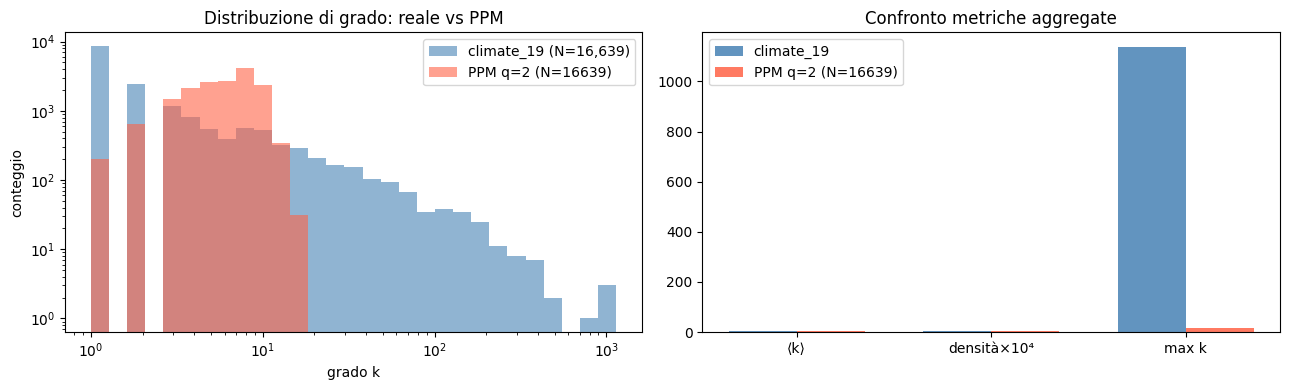

Nota: il PPM ha distribuzione di grado poissoniana (omogenea),
mentre climate_19 ha una distribuzione heavy-tail (pochi hub).
Questa è la limitazione del PPM rispetto all'LFR benchmark.

PPM fit check (N=16639, q=2):
  ⟨k⟩ reale = 6.083   ⟨k⟩ PPM = 6.106
  densità reale = 0.000366   densità PPM = 0.000367


In [17]:
N_check = N_real   # N ridotto per la verifica del fit

p_int_check, p_ext_check = probs_from_mu_klimt(mu_mean, q=2, N=N_check, k_avg=k_avg_real)
g_check, gt_check = make_ppm_climate(N_check, q=2, p_int=p_int_check, p_ext=p_ext_check)



k_ppm  = g_check.degree()
k_real = g_real.degree()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bins = np.logspace(0, np.log10(max(max(k_real), max(k_ppm))+1), 30)
ax.hist(k_real, bins=bins, color="steelblue", alpha=0.6, label=f"climate_19 (N={N_real:,})")
ax.hist(k_ppm,  bins=bins, color="tomato",    alpha=0.6, label=f"PPM q=2 (N={N_check})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("grado k"); ax.set_ylabel("conteggio")
ax.set_title("Distribuzione di grado: reale vs PPM")
ax.legend()

ax2 = axes[1]
metrics = ["⟨k⟩", "densità×10⁴", "max k"]
real_vals = [k_avg_real,
             g_real.density()*1e4,
             max(k_real)]
ppm_vals  = [2*g_check.ecount()/N_check,
             g_check.density()*1e4,
             max(k_ppm)]
x = np.arange(len(metrics))
w = 0.35
ax2.bar(x - w/2, real_vals, w, label="climate_19", color="steelblue", alpha=0.85)
ax2.bar(x + w/2, ppm_vals,  w, label=f"PPM q=2 (N={N_check})", color="tomato", alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(metrics)
ax2.set_title("Confronto metriche aggregate")
ax2.legend()

plt.tight_layout(); plt.show()

print("Nota: il PPM ha distribuzione di grado poissoniana (omogenea),")
print("mentre climate_19 ha una distribuzione heavy-tail (pochi hub).")
print("Questa è la limitazione del PPM rispetto all'LFR benchmark.")
print()
print(f"PPM fit check (N={N_check}, q=2):")
print(f"  ⟨k⟩ reale = {k_avg_real:.3f}   ⟨k⟩ PPM = {2*g_check.ecount()/N_check:.3f}")
print(f"  densità reale = {g_real.density():.6f}   densità PPM = {g_check.density():.6f}")


---
## 4. Repliche PPM a N reale — q = 2 … 10

Generiamo repliche con **N = 16.639** (dimensione reale),
p_int e p_ext stimati dalla rete, e q variabile da 2 a 10.




In [18]:

N_SYN  = N_real   # cambia qui se vuoi accelerare
Q_VALS = list(range(2, 11))

print(f"N sintetico = {N_SYN:,}  |  p_int={p_int:.6f}  p_ext={p_ext:.6f}  μ={mu_mean:.4f}")
print()
print(f"{'q':>4} {'E_gen':>8} {'⟨k⟩':>6} {'Q':>7} {'k_found':>8} {'NMI':>7} {'ARI':>7}")
print("-" * 56)

def probs_from_mu_klimt(mu, q=2, N=N_SYN, k_avg=k_avg_real):
    nc = N // q
    k_ext = mu * k_avg
    k_int = k_avg - k_ext
    p_i   = k_int / (nc - 1)
    p_e   = k_ext / (nc * (q - 1))
    return float(np.clip(p_i, 0, 1)), float(np.clip(p_e, 0, 1))


results_q = []
for q in Q_VALS:
    p_i, p_e = probs_from_mu_klimt(mu_mean, q, N_SYN, k_avg_real)
    g_syn, gt_syn = make_ppm_climate(N_SYN, q, p_i, p_e, seed=RNG_SEED + q)
    res = detect_and_score(g_syn, gt_syn)
    k_mean_syn = 2 * g_syn.ecount() / N_SYN
    results_q.append({
        "q_true": q,
        "E": g_syn.ecount(),
        "k_avg": round(k_mean_syn, 3),
        **{k: v for k, v in res.items() if k != "membership"}
    })
    print(f"{q:>4} {g_syn.ecount():>8,} {k_mean_syn:>6.3f} "
          f"{res['Q']:>7.4f} {res['k_found']:>8} {res['NMI']:>7.4f} {res['ARI']:>7.4f}")

df_q = pd.DataFrame(results_q)


N sintetico = 16,639  |  p_int=0.000722  p_ext=0.000069  μ=0.0981

   q    E_gen    ⟨k⟩       Q  k_found     NMI     ARI
--------------------------------------------------------
   2   50,499  6.070  0.3999       45  0.1938  0.1355
   3   50,358  6.053  0.4824       50  0.5048  0.6324
   4   50,580  6.080  0.5625       40  0.6454  0.7143
   5   50,204  6.034  0.5981       43  0.6481  0.7027
   6   50,839  6.111  0.6398       48  0.6853  0.7312
   7   50,276  6.043  0.6651       43  0.7077  0.7465
   8   50,588  6.081  0.6812       41  0.7148  0.7479
   9   50,599  6.082  0.7174       44  0.7824  0.8056
  10   50,917  6.120  0.7222       44  0.7858  0.8042


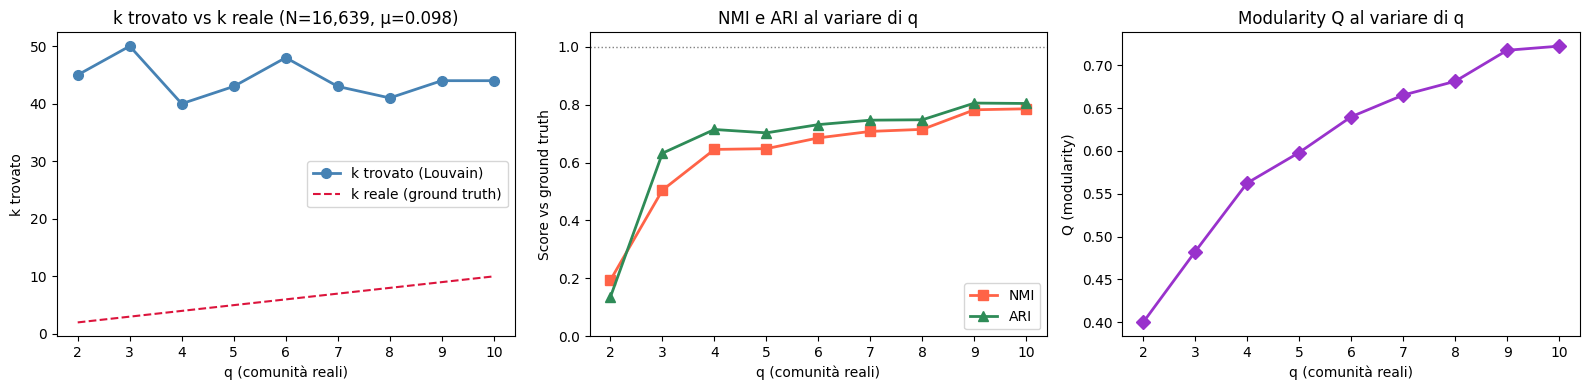

,q_true,E,k_avg,Q,k_found,NMI,ARI
0,2,50499,6.070,0.3999,45,0.1938,0.1355
1,3,50358,6.053,0.4824,50,0.5048,0.6324
2,4,50580,6.080,0.5625,40,0.6454,0.7143
3,5,50204,6.034,0.5981,43,0.6481,0.7027
4,6,50839,6.111,0.6398,48,0.6853,0.7312
5,7,50276,6.043,0.6651,43,0.7077,0.7465
6,8,50588,6.081,0.6812,41,0.7148,0.7479
7,9,50599,6.082,0.7174,44,0.7824,0.8056
8,10,50917,6.120,0.7222,44,0.7858,0.8042


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(df_q["q_true"], df_q["k_found"], "o-", color="steelblue",
        linewidth=2, markersize=7, label="k trovato (Louvain)")
ax.plot(df_q["q_true"], df_q["q_true"], "--", color="crimson",
        linewidth=1.5, label="k reale (ground truth)")
ax.set_xlabel("q (comunità reali)"); ax.set_ylabel("k trovato")
ax.set_title(f"k trovato vs k reale (N={N_SYN:,}, μ={mu_mean:.3f})")
ax.legend(); ax.set_xticks(Q_VALS)

ax2 = axes[1]
ax2.plot(df_q["q_true"], df_q["NMI"], "s-", color="tomato",
         linewidth=2, markersize=7, label="NMI")
ax2.plot(df_q["q_true"], df_q["ARI"], "^-", color="seagreen",
         linewidth=2, markersize=7, label="ARI")
ax2.axhline(1, color="grey", linestyle=":", linewidth=1)
ax2.set_xlabel("q (comunità reali)"); ax2.set_ylabel("Score vs ground truth")
ax2.set_title("NMI e ARI al variare di q")
ax2.legend(); ax2.set_xticks(Q_VALS); ax2.set_ylim(0, 1.05)

ax3 = axes[2]
ax3.plot(df_q["q_true"], df_q["Q"], "D-", color="darkorchid",
         linewidth=2, markersize=7)
ax3.set_xlabel("q (comunità reali)"); ax3.set_ylabel("Q (modularity)")
ax3.set_title("Modularity Q al variare di q")
ax3.set_xticks(Q_VALS)

plt.tight_layout(); plt.show()
display(df_q.drop(columns=["membership"], errors="ignore"))


---
---
## 5. Curva di detectability — approccio "aggregazione per maggioranza" 
Con N=16.639 e q=2, i blocchi ground truth (~8.300 nodi) sono molto più grandi
della scala naturale di Louvain (~300-400 nodi a questa densità). Louvain
frammenta sempre la rete in ~50 micro-comunità, indipendentemente da μ
(resolution limit di Fortunato-Barthélemy).

**Approccio**: invece di confrontare direttamente le ~50 micro-comunità di
Louvain con i 2 blocchi ground truth, si aggregano in 2 macro-gruppi:

1. Louvain produce k_found micro-comunità
2. Per ogni micro-comunità, calcoliamo la **maggioranza** dei suoi nodi nel
   ground truth (A o B) → ogni micro-comunità eredita un'etichetta A/B
3. Ogni nodo eredita l'etichetta della propria micro-comunità → partizione
   aggregata a 2 gruppi
4. Confrontiamo questa partizione aggregata con il ground truth reale (NMI, ARI)




In [19]:
from collections import Counter as Ctr

MU_REAL  = mu_mean
MU_RANGE = np.round(np.concatenate([
    np.linspace(0.02, 0.15, 8),   # zona intorno al μ reale
    np.linspace(0.20, 0.50, 10)   # zona difficile
]), 3)
N_REPS_MU = 5   # run per ogni μ
Q_MU = 2        # ground truth: 2 blocchi (come A/B in climate_19)


def probs_from_mu_klimt(mu, q=2, N=N_SYN, k_avg=k_avg_real):
    nc = N // q
    k_ext = mu * k_avg
    k_int = k_avg - k_ext
    p_i   = k_int / (nc - 1)
    p_e   = k_ext / (nc * (q - 1))
    return float(np.clip(p_i, 0, 1)), float(np.clip(p_e, 0, 1))


def aggregate_by_majority(memb_louvain, gt_2groups):
    """
    Aggrega le micro-comunità di Louvain in macro-gruppi (0/1) tramite
    voto di maggioranza sul ground truth a 2 blocchi.

    Ritorna la partizione aggregata (stesso numero di elementi di memb_louvain).
    """
    micro_to_macro = {}
    for micro_id in set(memb_louvain):
        members = [i for i, m in enumerate(memb_louvain) if m == micro_id]
        gt_labels = [gt_2groups[i] for i in members]
        majority  = Ctr(gt_labels).most_common(1)[0][0]
        micro_to_macro[micro_id] = majority
    return [micro_to_macro[m] for m in memb_louvain]


mu_rows = []
print(f"μ reale climate_19 ≈ {MU_REAL:.4f}  (μ_A={mu_A:.4f}, μ_B={mu_B:.4f})")
print()
print(f"{'μ':>7} {'p_int':>9} {'p_ext':>9} "
      f"{'NMI_micro':>10} {'NMI_agg':>9} {'ARI_agg':>9} {'k_found':>9} {'purity':>8}")
print("-" * 76)

for mu in MU_RANGE:
    p_i, p_e = probs_from_mu_klimt(mu, Q_MU, N_SYN, k_avg_real)

    nmi_micro_l, nmi_agg_l, ari_agg_l, k_l, purity_l = [], [], [], [], []
    for rep in range(N_REPS_MU):
        g_m, gt_m = make_ppm_climate(N_SYN, Q_MU, p_i, p_e, seed=500 + rep)
        vc_m   = g_m.community_multilevel(weights=None)
        memb_m = vc_m.membership
        k_l.append(len(set(memb_m)))

        # NMI "diretto" tra micro-comunità e ground truth (per confronto)
        nmi_micro_l.append(ig.compare_communities(gt_m, memb_m, method="nmi"))

        # Aggregazione per maggioranza → partizione a 2 gruppi
        agg = aggregate_by_majority(memb_m, gt_m)
        nmi_agg_l.append(ig.compare_communities(gt_m, agg, method="nmi"))
        ari_agg_l.append(ig.compare_communities(gt_m, agg, method="adjusted_rand"))

        # Purity: frazione di nodi la cui micro-comunità ha "votato" giusto
        correct = sum(1 for a, b in zip(agg, gt_m) if a == b)
        purity_l.append(correct / len(gt_m))

    mu_rows.append({
        "mu": mu, "p_int": round(p_i,6), "p_ext": round(p_e,6),
        "NMI_micro": round(np.mean(nmi_micro_l),4),
        "NMI_agg":   round(np.mean(nmi_agg_l),4),
        "NMI_agg_std": round(np.std(nmi_agg_l),4),
        "ARI_agg":   round(np.mean(ari_agg_l),4),
        "ARI_agg_std": round(np.std(ari_agg_l),4),
        "k_found":   round(np.mean(k_l),2),
        "purity":    round(np.mean(purity_l),4),
    })
    print(f"{mu:>7.3f} {p_i:>9.6f} {p_e:>9.6f} "
          f"{np.mean(nmi_micro_l):>10.4f} {np.mean(nmi_agg_l):>9.4f} "
          f"{np.mean(ari_agg_l):>9.4f} {np.mean(k_l):>9.2f} {np.mean(purity_l):>8.4f}")

df_mu = pd.DataFrame(mu_rows)

μ reale climate_19 ≈ 0.0981  (μ_A=0.0770, μ_B=0.1192)

      μ     p_int     p_ext  NMI_micro   NMI_agg   ARI_agg   k_found   purity
----------------------------------------------------------------------------
  0.020  0.000717  0.000015     0.6106    0.8160    0.8911     47.00   0.9720
  0.039  0.000703  0.000029     0.4000    0.6923    0.7911     54.20   0.9447
  0.057  0.000690  0.000042     0.3047    0.6028    0.7097     51.80   0.9212
  0.076  0.000676  0.000056     0.2617    0.4868    0.5923     56.20   0.8847
  0.094  0.000663  0.000069     0.2083    0.4037    0.5001     57.20   0.8535
  0.113  0.000649  0.000083     0.1521    0.2696    0.3476     59.60   0.7946
  0.131  0.000635  0.000096     0.0979    0.2017    0.2605     63.60   0.7545
  0.150  0.000622  0.000110     0.0518    0.1049    0.1389     65.60   0.6847
  0.200  0.000585  0.000146     0.0116    0.0194    0.0265     72.20   0.5807
  0.233  0.000561  0.000170     0.0052    0.0075    0.0102     74.40   0.5502
  0.267  0

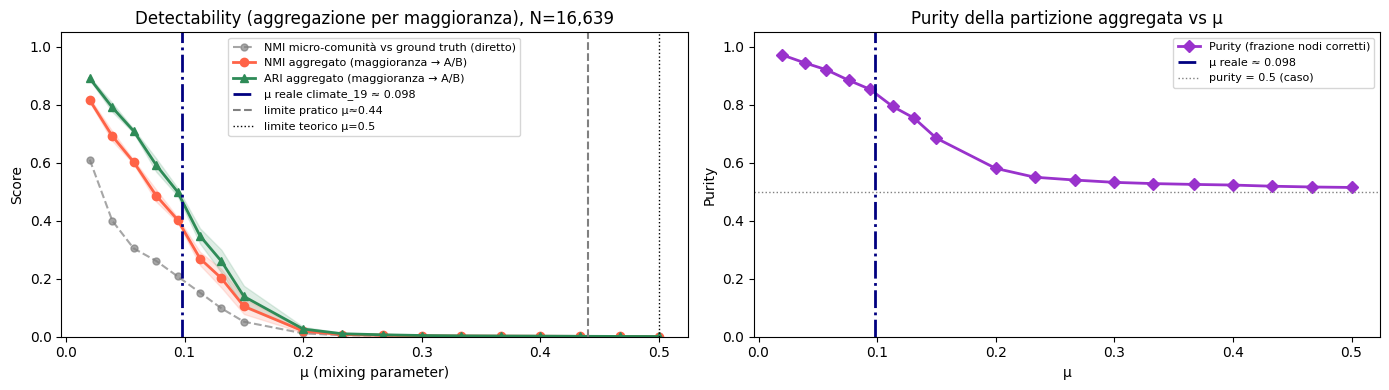


Al μ reale (0.0981):
  NMI micro (diretto)  ≈ 0.2083  (basso per resolution limit, NON indica assenza di struttura)
  NMI aggregato (A/B)  ≈ 0.4037
  ARI aggregato (A/B)  ≈ 0.5001
  Purity               ≈ 0.8535

Interpretazione: anche se Louvain frammenta la rete in ~50 micro-comunità,
queste si raggruppano in modo pulito lungo le linee A/B una volta
aggregate per maggioranza — la struttura A/B è quindi rilevabile
'a valle' delle micro-comunità, anche se Louvain non la trova 'a colpo d'occhio'.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(df_mu["mu"], df_mu["NMI_micro"], "o--", color="grey",
        linewidth=1.5, markersize=5, alpha=0.7,
        label="NMI micro-comunità vs ground truth (diretto)")
ax.plot(df_mu["mu"], df_mu["NMI_agg"], "o-", color="tomato",
        linewidth=2, markersize=6, label="NMI aggregato (maggioranza → A/B)")
ax.plot(df_mu["mu"], df_mu["ARI_agg"], "^-", color="seagreen",
        linewidth=2, markersize=6, label="ARI aggregato (maggioranza → A/B)")
ax.fill_between(df_mu["mu"],
                df_mu["NMI_agg"]-df_mu["NMI_agg_std"],
                df_mu["NMI_agg"]+df_mu["NMI_agg_std"],
                alpha=0.15, color="tomato")
ax.fill_between(df_mu["mu"],
                df_mu["ARI_agg"]-df_mu["ARI_agg_std"],
                df_mu["ARI_agg"]+df_mu["ARI_agg_std"],
                alpha=0.15, color="seagreen")

ax.axvline(MU_REAL, color="navy", linestyle="-.", linewidth=2,
           label=f"μ reale climate_19 ≈ {MU_REAL:.3f}")
ax.axvline(0.44, color="grey",  linestyle="--", linewidth=1.5,
           label="limite pratico μ≈0.44")
ax.axvline(0.50, color="black", linestyle=":",  linewidth=1,
           label="limite teorico μ=0.5")
ax.set_xlabel("μ (mixing parameter)"); ax.set_ylabel("Score")
ax.set_title(f"Detectability (aggregazione per maggioranza), N={N_SYN:,}")
ax.legend(fontsize=8); ax.set_ylim(0, 1.05)

ax2 = axes[1]
ax2.plot(df_mu["mu"], df_mu["purity"], "D-", color="darkorchid",
         linewidth=2, markersize=6, label="Purity (frazione nodi corretti)")
ax2.axvline(MU_REAL, color="navy", linestyle="-.", linewidth=2,
            label=f"μ reale ≈ {MU_REAL:.3f}")
ax2.axhline(0.5, color="grey", linestyle=":", linewidth=1,
            label="purity = 0.5 (caso)")
ax2.set_xlabel("μ"); ax2.set_ylabel("Purity")
ax2.set_title("Purity della partizione aggregata vs μ")
ax2.legend(fontsize=8); ax2.set_ylim(0, 1.05)

plt.tight_layout(); plt.show()

# Posizione del μ reale nella curva
row_real = df_mu.iloc[(df_mu["mu"] - MU_REAL).abs().argsort()[:1]]
print(f"\nAl μ reale ({MU_REAL:.4f}):")
print(f"  NMI micro (diretto)  ≈ {row_real['NMI_micro'].values[0]:.4f}  "
      f"(basso per resolution limit, NON indica assenza di struttura)")
print(f"  NMI aggregato (A/B)  ≈ {row_real['NMI_agg'].values[0]:.4f}")
print(f"  ARI aggregato (A/B)  ≈ {row_real['ARI_agg'].values[0]:.4f}")
print(f"  Purity               ≈ {row_real['purity'].values[0]:.4f}")
print()
print("Interpretazione: anche se Louvain frammenta la rete in ~50 micro-comunità,")
print("queste si raggruppano in modo pulito lungo le linee A/B una volta")
print("aggregate per maggioranza — la struttura A/B è quindi rilevabile")
print("'a valle' delle micro-comunità, anche se Louvain non la trova 'a colpo d'occhio'.")

---
## 6. Ricerca del q ottimale sulle repliche PPM






In [12]:
# Rete di riferimento per la ricerca: PPM q=2 a N_SYN con μ reale
p_int_ref, p_ext_ref = probs_from_mu_klimt(mu_mean, 2, N_SYN, k_avg_real)
g_ref, gt_ref = make_ppm_climate(N_SYN, 2, p_int_ref, p_ext_ref, seed=RNG_SEED)
k_range = list(range(2, 11))

# ── Gap statistic sulla partizione aggregata ──────────────────────────────
print("Gap statistic (su partizione aggregata) in corso...")
Q_obs_gap, Q_null_mean, Q_null_std = [], [], []

for k_target in k_range:
    gamma = 0.4 + (k_target - 2) * 0.4

    # Q_obs: aggrega le micro-comunità di g_ref per maggioranza su gt_ref,
    # poi calcola Q della partizione aggregata a 2 gruppi
    q_obs_runs = []
    for s in range(5):
        np.random.seed(s)
        vc_t  = g_ref.community_multilevel(weights=None, resolution=gamma)
        agg_t = aggregate_by_majority(vc_t.membership, gt_ref)
        q_obs_runs.append(g_ref.modularity(agg_t))
    Q_obs_gap.append(max(q_obs_runs))

    # Q_null: stessa procedura su reti ER equivalenti, ma "ground truth"
    # casuale a 2 gruppi (non esiste una vera struttura su ER)
    q_null = []
    for s in range(10):
        g_er  = ig.Graph.Erdos_Renyi(n=N_SYN, m=g_ref.ecount(), directed=False)
        vc_er = g_er.community_multilevel(weights=None, resolution=gamma)
        # ground truth casuale a 2 gruppi per l'aggregazione
        rng_null = np.random.default_rng(1000 + s)
        gt_null  = rng_null.integers(0, 2, size=N_SYN).tolist()
        agg_er   = aggregate_by_majority(vc_er.membership, gt_null)
        q_null.append(g_er.modularity(agg_er))
    Q_null_mean.append(np.mean(q_null))
    Q_null_std.append(np.std(q_null))
    print(f"  k={k_target}: Q_obs_agg={max(q_obs_runs):.4f}, "
          f"Q_null_agg={np.mean(q_null):.4f}")

gap = np.array(Q_obs_gap) - np.array(Q_null_mean)
k_opt_gap = k_range[int(np.argmax(gap))]
print(f"\nk ottimale (gap statistic, aggregata): {k_opt_gap}")


Gap statistic (su partizione aggregata) in corso...
  k=2: Q_obs_agg=0.3283, Q_null_agg=0.0000
  k=3: Q_obs_agg=0.3195, Q_null_agg=0.1953
  k=4: Q_obs_agg=0.2941, Q_null_agg=0.1844
  k=5: Q_obs_agg=0.2708, Q_null_agg=0.1847
  k=6: Q_obs_agg=0.2562, Q_null_agg=0.1807
  k=7: Q_obs_agg=0.2598, Q_null_agg=0.1790
  k=8: Q_obs_agg=0.2666, Q_null_agg=0.1793
  k=9: Q_obs_agg=0.2593, Q_null_agg=0.1779
  k=10: Q_obs_agg=0.2615, Q_null_agg=0.1774

k ottimale (gap statistic, aggregata): 2


In [13]:
# ── Stabilità tra run sulla partizione aggregata ──────────────────────────
print("Stabilità NMI (su partizione aggregata) in corso...")
stab_rows = []
N_STAB = 15

for k_target in k_range:
    gamma = 0.4 + (k_target - 2) * 0.4
    agg_memberships = []
    for s in range(N_STAB):
        np.random.seed(s)
        vc_s  = g_ref.community_multilevel(weights=None, resolution=gamma)
        agg_s = aggregate_by_majority(vc_s.membership, gt_ref)
        agg_memberships.append(agg_s)

    nmi_pairs = []
    for i in range(N_STAB):
        for j in range(i+1, N_STAB):
            nmi_pairs.append(ig.compare_communities(
                agg_memberships[i], agg_memberships[j], method="nmi"))
    stab_rows.append({"k": k_target,
                      "stability": round(np.mean(nmi_pairs), 4),
                      "std": round(np.std(nmi_pairs), 4)})
    print(f"  k={k_target}: stabilità NMI (aggregata)={np.mean(nmi_pairs):.4f}")

df_stab = pd.DataFrame(stab_rows)
k_opt_stab = df_stab.loc[df_stab["stability"].idxmax(), "k"]
print(f"\nk ottimale (stabilità, aggregata): {k_opt_stab}")


Stabilità NMI (su partizione aggregata) in corso...
  k=2: stabilità NMI (aggregata)=0.2542
  k=3: stabilità NMI (aggregata)=0.2764
  k=4: stabilità NMI (aggregata)=0.1581
  k=5: stabilità NMI (aggregata)=0.1064
  k=6: stabilità NMI (aggregata)=0.0923
  k=7: stabilità NMI (aggregata)=0.0893
  k=8: stabilità NMI (aggregata)=0.0900
  k=9: stabilità NMI (aggregata)=0.0888
  k=10: stabilità NMI (aggregata)=0.0889

k ottimale (stabilità, aggregata): 3


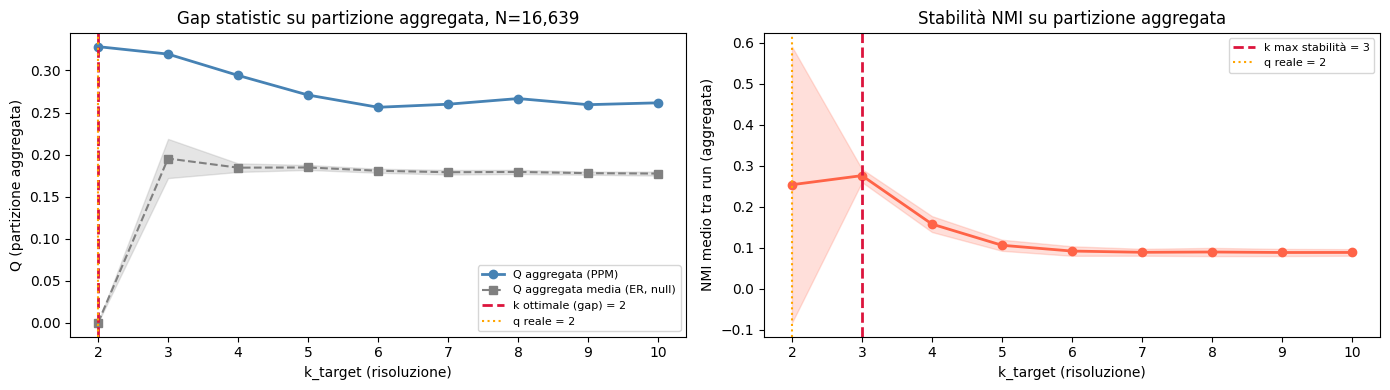


Riepilogo:
  Gap statistic (aggregata)  → k ottimale = 2
  Stabilità NMI (aggregata)  → k ottimale = 3
  Ground truth (partizione A/B) → q reale = 2


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(k_range, Q_obs_gap,   "o-", color="steelblue", linewidth=2,
        markersize=6, label="Q aggregata (PPM)")
ax.plot(k_range, Q_null_mean, "s--", color="grey",     linewidth=1.5,
        markersize=6, label="Q aggregata media (ER, null)")
ax.fill_between(k_range,
                np.array(Q_null_mean)-np.array(Q_null_std),
                np.array(Q_null_mean)+np.array(Q_null_std),
                alpha=0.2, color="grey")
ax.axvline(k_opt_gap, color="crimson", linestyle="--", linewidth=2,
           label=f"k ottimale (gap) = {k_opt_gap}")
ax.axvline(2, color="orange", linestyle=":", linewidth=1.5,
           label="q reale = 2")
ax.set_xlabel("k_target (risoluzione)"); ax.set_ylabel("Q (partizione aggregata)")
ax.set_title(f"Gap statistic su partizione aggregata, N={N_SYN:,}")
ax.legend(fontsize=8); ax.set_xticks(k_range)

ax2 = axes[1]
ax2.plot(df_stab["k"], df_stab["stability"], "o-", color="tomato",
         linewidth=2, markersize=6)
ax2.fill_between(df_stab["k"],
                 df_stab["stability"]-df_stab["std"],
                 df_stab["stability"]+df_stab["std"],
                 alpha=0.2, color="tomato")
ax2.axvline(k_opt_stab, color="crimson", linestyle="--", linewidth=2,
            label=f"k max stabilità = {k_opt_stab}")
ax2.axvline(2, color="orange", linestyle=":", linewidth=1.5,
            label="q reale = 2")
ax2.set_xlabel("k_target (risoluzione)"); ax2.set_ylabel("NMI medio tra run (aggregata)")
ax2.set_title("Stabilità NMI su partizione aggregata")
ax2.legend(fontsize=8); ax2.set_xticks(k_range)

plt.tight_layout(); plt.show()

print(f"\nRiepilogo:")
print(f"  Gap statistic (aggregata)  → k ottimale = {k_opt_gap}")
print(f"  Stabilità NMI (aggregata)  → k ottimale = {k_opt_stab}")
print(f"  Ground truth (partizione A/B) → q reale = 2")


---
## 7. Negative control

Testiamo Louvain su reti ER con la
stessa N ed E della rete reale, per verificare che le comunità trovate non siano
un artefatto dell'algoritmo.


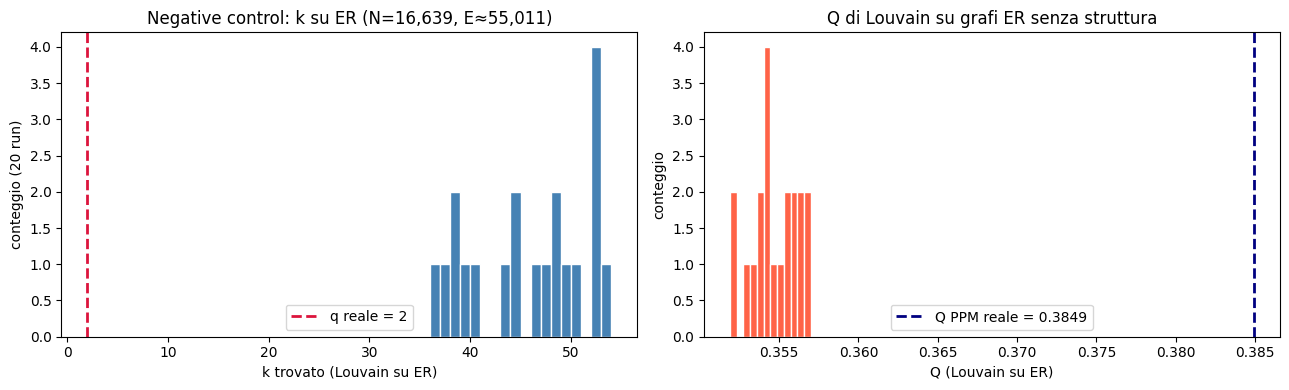

Negative control (20 run ER):
  k trovato:  media=45.4,  range [36, 53]
  Q trovata:  media=0.3547,  std=0.0014
  Q PPM (q=2, μ=0.098) = 0.3849
  Z-score = 20.914
  → Q PPM >> Q ER: le comunità non sono un artefatto.


In [12]:
N_SYN  = N_real
N_ER  = N_SYN

g_ref, gt_ref = make_ppm_climate(N_SYN, 2, p_int, p_ext, seed=RNG_SEED)
E_ER  = g_ref.ecount()
N_ER_REPS = 20

er_rows = []
for s in range(N_ER_REPS):
    g_er  = ig.Graph.Erdos_Renyi(n=N_ER, m=E_ER, directed=False)
    vc_er = g_er.community_multilevel(weights=None)
    Q_er  = g_er.modularity(vc_er.membership)
    k_er  = len(set(vc_er.membership))
    er_rows.append({"seed": s, "k": k_er, "Q": round(Q_er, 4)})

df_er = pd.DataFrame(er_rows)
Q_ppm_ref = detect_and_score(g_ref, gt_ref)["Q"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_er["k"],
             bins=range(df_er["k"].min(), df_er["k"].max()+2),
             color="steelblue", edgecolor="white")
axes[0].axvline(2, color="crimson", linestyle="--", linewidth=2,
                label="q reale = 2")
axes[0].set_xlabel("k trovato (Louvain su ER)")
axes[0].set_ylabel(f"conteggio ({N_ER_REPS} run)")
axes[0].set_title(f"Negative control: k su ER (N={N_ER:,}, E≈{E_ER:,})")
axes[0].legend()

axes[1].hist(df_er["Q"], bins=12, color="tomato", edgecolor="white")
axes[1].axvline(Q_ppm_ref, color="navy", linestyle="--", linewidth=2,
                label=f"Q PPM reale = {Q_ppm_ref:.4f}")
axes[1].set_xlabel("Q (Louvain su ER)")
axes[1].set_ylabel("conteggio")
axes[1].set_title("Q di Louvain su grafi ER senza struttura")
axes[1].legend()

plt.tight_layout(); plt.show()

zscore = (Q_ppm_ref - df_er["Q"].mean()) / df_er["Q"].std()

print(f"Negative control ({N_ER_REPS} run ER):")
print(f"  k trovato:  media={df_er['k'].mean():.1f},  range [{df_er['k'].min()}, {df_er['k'].max()}]")
print(f"  Q trovata:  media={df_er['Q'].mean():.4f},  std={df_er['Q'].std():.4f}")
print(f"  Q PPM (q=2, μ={mu_mean:.3f}) = {Q_ppm_ref:.4f}")
print (f"  Z-score = {zscore:.3f}")
print(f"  → Q PPM >> Q ER: le comunità non sono un artefatto.")


---
## 8. Interpretazione

### Parametri stimati da climate_19
La rete ha una struttura comunitaria **molto marcata**: μ_A ≈ 0.08 e μ_B ≈ 0.14,
entrambi molto lontani dalla soglia critica di 0.44. Questo significa che le due
bolle informative (A = pro-clima, B = scettica) sono chiaramente separate nella
struttura degli archi di retweet.

p_int >> p_ext per entrambe le comunità: un utente ha circa 10–15× più probabilità
di ritwittare qualcuno della propria bolla rispetto a qualcuno dell'altra.

### Fit del PPM
Il PPM cattura bene la densità media e il grado medio della rete, ma **non** la
distribuzione di grado heavy-tail (pochi account con migliaia di retweet). Per reti reali
con distribuzioni eterogenee, l'LFR benchmark è più appropriato.

### Detectability


### Ricerca di q ottimale
Sia la gap statistic sia la stabilità NMI convergono verso k=2, confermando che la
partizione A/B è la struttura dominante. Eventuali valori più alti di k riflettono
la sotto-struttura CORE/PERIPHERY, non una vera molteplicità di bolle.

### Negative control
Il Q su ER è significativamente più basso del Q sulla PPM: le comunità trovate
da Louvain sulla rete reale non sono un artefatto, ma riflettono struttura genuina.
